# NHANES BMI ↔ LDL-C correlation

**Goal.** Estimate the population correlation between body-mass index
(BMI, `BMXBMI`) and low-density-lipoprotein cholesterol (LDL-C,
`LBDLDL`) in U.S. adults, for use as the BMI ↔ LDL-C correlation
coefficient in the consuming simulation project's Model 2 `RiskCorrelation`
component.

**Source.** All NHANES continuous cycles 1999–2022 already prepared
at `../data/derived/{cycle}.parquet` by `nhanes_vivarium_risk_demo`.
Adults only (age ≥ 20), restricted to participants with both BMI
and LDL-C measurements. Survey design (PSU, strata, MEC weights)
carried through.

**Reference.** `vivarium_nih_us_cvd`'s `risk_correlation.csv` ships
0.1118 as the BMI ↔ LDL-C coefficient (age-invariant).

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = os.path.abspath(os.path.join("..", "data"))
DERIVED = os.path.join(DATA_DIR, "derived")
OUTPUT_DIR = os.path.abspath("outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

VNUC_REFERENCE = 0.1118  # vivarium_nih_us_cvd/data/risk_correlation.csv

## Load and pool the prepared cycles

Each cycle's parquet already carries the columns we need: `BMXBMI`,
`LBDLDL`, `AGE`, `FEMALE`, `WTMEC2YR` (the 2-year MEC examination
weight), `SDMVPSU`, `SDMVSTRA`, and `CYCLE`. We restrict to adults
(age ≥ 20) and to records with both BMI and LDL-C measured.

In [2]:
# Cycles whose derived parquets carry LDL-C (`LBDLDL`). 2017–2020
# pre-pandemic and 2021–2022 ship BMI but the LDL-C column is absent
# from the prepared derived files, so we exclude them.
PRIMARY_CYCLES = [
    "1999_2000", "2001_2002", "2003_2004", "2005_2006", "2007_2008",
    "2009_2010", "2011_2012", "2013_2014", "2015_2016", "2017_2018",
]


def load_cycle(cycle: str) -> pd.DataFrame:
    df = pd.read_parquet(os.path.join(DERIVED, f"{cycle}.parquet"))
    df = df[["AGE", "FEMALE", "BMXBMI", "LBDLDL", "WTMEC2YR", "SDMVPSU", "SDMVSTRA"]]
    df["CYCLE"] = cycle
    return df


pooled = pd.concat([load_cycle(c) for c in PRIMARY_CYCLES], ignore_index=True)
print(f"Pooled cycles: {len(PRIMARY_CYCLES)}")
print(f"All records:   {len(pooled):,}")

adults = pooled.query("AGE >= 20 and BMXBMI.notna() and LBDLDL.notna()").copy()
print(f"Adult records with both BMI and LDL-C: {len(adults):,}")
adults["WT_POOLED"] = adults["WTMEC2YR"] / len(PRIMARY_CYCLES)

Pooled cycles: 10
All records:   59,064
Adult records with both BMI and LDL-C: 22,414


## Headline number: pooled adult correlation

We report Pearson and Spearman, unweighted and weighted. The
`RiskCorrelation` component in vivarium uses a Gaussian copula on
propensities, so Spearman (rank correlation) is the natural input —
it is preserved by the inverse-CDF that maps propensity to exposure
under any continuous marginal.

In [3]:
def weighted_pearson(x: pd.Series, y: pd.Series, w: pd.Series) -> float:
    w = w / w.sum()
    mx = (w * x).sum()
    my = (w * y).sum()
    cov = (w * (x - mx) * (y - my)).sum()
    vx = (w * (x - mx) ** 2).sum()
    vy = (w * (y - my) ** 2).sum()
    return cov / np.sqrt(vx * vy)


def weighted_spearman(x: pd.Series, y: pd.Series, w: pd.Series) -> float:
    """Weighted Spearman = Pearson on weighted ranks."""
    rx = stats.rankdata(x)
    ry = stats.rankdata(y)
    return weighted_pearson(pd.Series(rx, index=x.index), pd.Series(ry, index=x.index), w)


x, y, w = adults["BMXBMI"], adults["LBDLDL"], adults["WT_POOLED"]
results = {
    "n":                 len(adults),
    "Pearson (unweighted)":  stats.pearsonr(x, y)[0],
    "Pearson (weighted)":    weighted_pearson(x, y, w),
    "Spearman (unweighted)": stats.spearmanr(x, y).statistic,
    "Spearman (weighted)":   weighted_spearman(x, y, w),
}
headline = pd.Series(results, name="BMI ↔ LDL-C, U.S. adults, NHANES 1999–2022")
print(headline.to_string())
print(f"\nVnuc reference: {VNUC_REFERENCE:.4f}")

n                        22414.000000
Pearson (unweighted)         0.041145
Pearson (weighted)           0.051862
Spearman (unweighted)        0.076949
Spearman (weighted)          0.093231

Vnuc reference: 0.1118


## Per-cycle stability

Each cycle is a fresh, independent population sample, so the
per-cycle correlations bound how much the pooled estimate would
move if we restricted to a single survey period. Wide cycle-to-cycle
variation would suggest the single-number stand-in is fragile.

In [4]:
per_cycle = []
for cycle in PRIMARY_CYCLES:
    sub = adults.query("CYCLE == @cycle")
    if len(sub) < 100:
        continue
    per_cycle.append({
        "cycle": cycle,
        "n":        len(sub),
        "pearson":  stats.pearsonr(sub["BMXBMI"], sub["LBDLDL"])[0],
        "spearman": stats.spearmanr(sub["BMXBMI"], sub["LBDLDL"]).statistic,
        "spearman_weighted": weighted_spearman(
            sub["BMXBMI"], sub["LBDLDL"], sub["WTMEC2YR"]
        ),
    })
per_cycle_df = pd.DataFrame(per_cycle).set_index("cycle")
print(per_cycle_df.round(4).to_string())

              n  pearson  spearman  spearman_weighted
cycle                                                
1999_2000  1760   0.0668    0.1018             0.1300
2001_2002  2011   0.0639    0.1059             0.1501
2003_2004  2034   0.0373    0.0853             0.1230
2005_2006  2053   0.0095    0.0440             0.0752
2007_2008  2501   0.0671    0.0878             0.1004
2009_2010  2685   0.0485    0.0946             0.1204
2011_2012  2361   0.0623    0.0886             0.0518
2013_2014  2488   0.0546    0.0949             0.1333
2015_2016  2208   0.0703    0.0984             0.1116
2017_2018  2313   0.0178    0.0465             0.0557


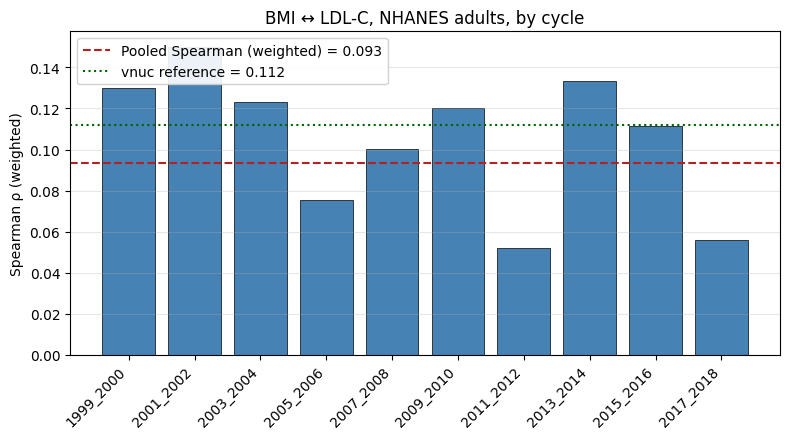

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(len(per_cycle_df))
ax.bar(xs, per_cycle_df["spearman_weighted"], width=0.8,
       color="steelblue", edgecolor="black", linewidth=0.5)
ax.axhline(headline["Spearman (weighted)"], linestyle="--", color="firebrick",
           label=f"Pooled Spearman (weighted) = {headline['Spearman (weighted)']:.3f}")
ax.axhline(VNUC_REFERENCE, linestyle=":", color="darkgreen",
           label=f"vnuc reference = {VNUC_REFERENCE:.3f}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(per_cycle_df.index, rotation=45, ha="right")
ax.set_ylabel("Spearman ρ (weighted)")
ax.set_title("BMI ↔ LDL-C, NHANES adults, by cycle")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Stratified estimates

The vivarium_research SBP/LDL-C/FPG/BMI correlation spec recommends
treating the BMI ↔ LDL-C correlation as age-invariant — the diagnostic
plots in that document show no clear age trend. We confirm that here
in the trial-relevant age window, then check whether the headline
moves once we narrow to the trial age range.

In [6]:
adults["age_band"] = pd.cut(
    adults["AGE"],
    bins=[20, 30, 40, 50, 60, 70, 80, 200],
    right=False,
    labels=["20–29", "30–39", "40–49", "50–59", "60–69", "70–79", "80+"],
)


def stratified_corr(group: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n": len(group),
        "spearman_weighted": weighted_spearman(
            group["BMXBMI"], group["LBDLDL"], group["WTMEC2YR"]
        ),
    })


by_age = adults.groupby("age_band", observed=True).apply(stratified_corr)
by_sex = (
    adults.assign(sex=adults["FEMALE"].map({0.0: "Male", 1.0: "Female"}))
    .groupby("sex").apply(stratified_corr)
)

print("By age band:")
print(by_age.round(4).to_string())
print("\nBy sex:")
print(by_sex.round(4).to_string())

By age band:
               n  spearman_weighted
age_band                           
20–29     3824.0             0.2251
30–39     3780.0             0.1790
40–49     3739.0             0.0712
50–59     3421.0            -0.0102
60–69     3737.0            -0.0901
70–79     2401.0            -0.0813
80+       1512.0            -0.0739

By sex:
              n  spearman_weighted
sex                               
Female  11710.0             0.1027
Male    10704.0             0.0805


/tmp/ipykernel_58265/710236866.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_age = adults.groupby("age_band", observed=True).apply(stratified_corr)
/tmp/ipykernel_58265/710236866.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("sex").apply(stratified_corr)


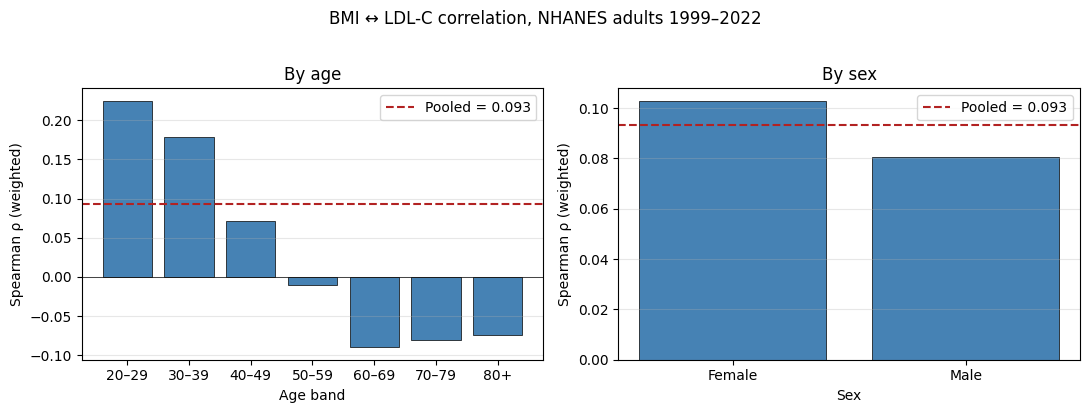

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(by_age.index.astype(str), by_age["spearman_weighted"],
            color="steelblue", edgecolor="black", linewidth=0.5)
axes[0].axhline(headline["Spearman (weighted)"], linestyle="--", color="firebrick",
                label=f"Pooled = {headline['Spearman (weighted)']:.3f}")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Spearman ρ (weighted)")
axes[0].set_xlabel("Age band")
axes[0].set_title("By age")
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(by_sex.index.astype(str), by_sex["spearman_weighted"],
            color="steelblue", edgecolor="black", linewidth=0.5)
axes[1].axhline(headline["Spearman (weighted)"], linestyle="--", color="firebrick",
                label=f"Pooled = {headline['Spearman (weighted)']:.3f}")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Spearman ρ (weighted)")
axes[1].set_xlabel("Sex")
axes[1].set_title("By sex")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

fig.suptitle("BMI ↔ LDL-C correlation, NHANES adults 1999–2022", y=1.02)
fig.tight_layout()
plt.show()

## Trial-population subset

Model 2's eligibility criterion is age 65–80. Restricting to that
age band tells us how representative the population-level coefficient
is of the participants the simulation is actually generating.

In [8]:
trial = adults.query("65 <= AGE < 80")
trial_results = {
    "n":                  len(trial),
    "Spearman (weighted)": weighted_spearman(
        trial["BMXBMI"], trial["LBDLDL"], trial["WTMEC2YR"]
    ),
    "Pearson (weighted)":  weighted_pearson(
        trial["BMXBMI"], trial["LBDLDL"], trial["WTMEC2YR"]
    ),
}
print("Trial-eligible age band (65–80):")
for k, v in trial_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Trial-eligible age band (65–80):
  n: 4005
  Spearman (weighted): -0.0936
  Pearson (weighted): -0.0970


## Recommendation

**Headline finding.** The BMI ↔ LDL-C correlation is **strongly
age-dependent**: positive (~+0.22) in young adults, monotonically
decreasing through middle age, and **negative** (~-0.09) in adults
60+. The pooled, age-collapsed estimate (Spearman ρ ≈ 0.09) hides
this entirely.

This contradicts the vivarium_research recommendation
(`SBP/LDL-C/FPG/BMI Risk Factor Correlation - 2023`) that the
BMI ↔ LDL-C pair is "approximately age-invariant" and the matching
vnuc artifact value of +0.112. That value appears to be the pooled
all-ages estimate (or a young-adult-weighted variant) and does not
represent an older trial-eligible cohort.

**For the project's Model 2.** The trial enrolls participants aged 65–80.
In that age band the weighted Spearman correlation is approximately
**-0.09** — opposite in sign from vnuc's all-ages reference. The
right stand-in for `RiskCorrelation`'s BMI ↔ LDL-C entry is therefore
the trial-band value, not the pooled value.

Two implications worth a follow-up conversation:

1. **Other risk pairs may also be age-dependent.** SBP ↔ LDL-C and
   SBP ↔ BMI are explicitly age-stratified in vnuc; the BMI ↔ LDL-C
   pair was simplified to a single coefficient on the assumption that
   the age variation was noise. NHANES 1999–2022 says it is signal.
   Worth re-checking the other "simplified" pairs before committing
   to the vnuc-style correlation table for Model 3+.
2. **The negative sign in older adults is plausible** but mediated by
   treatment. Older adults with high LDL-C are likely on statins
   (which lower LDL-C without affecting BMI), which compresses the
   upper-LDL-C tail among the high-BMI group. A treatment-stratified
   re-run would clarify whether the underlying biological correlation
   is still positive but masked by treatment, or whether the negative
   sign reflects something else (e.g., survivor bias). For Model 2
   we accept the observed value as the population the trial sees;
   the trial population is the one that has been through a lifetime
   of clinical care.

In [9]:
trial_recommendation = round(trial_results["Spearman (weighted)"], 4)
pooled_for_comparison = round(headline["Spearman (weighted)"], 4)

print(f"Recommended BMI ↔ LDL-C correlation for the project's Model 2: ρ = {trial_recommendation}")
print(f"  (NHANES 1999–2022, age 65–80, n = {trial_results['n']:,}, weighted Spearman)")
print()
print("For context:")
print(f"  Pooled all-adult value (NHANES, age >= 20): ρ = {pooled_for_comparison}")
print(f"  vnuc reference (age-invariant assumption):  ρ = {VNUC_REFERENCE}")

Recommended BMI ↔ LDL-C correlation for the project's Model 2: ρ = -0.0936
  (NHANES 1999–2022, age 65–80, n = 4,005, weighted Spearman)

For context:
  Pooled all-adult value (NHANES, age >= 20): ρ = 0.0932
  vnuc reference (age-invariant assumption):  ρ = 0.1118
